# India used car price pridiction


The aim of this project is to predict the price of used cars by analyzing various car features such as  brand, car model name, kilometers driven,car_price_in_rupees, fuel type, car age,  and city. This project also aims to identify the set of variables that have the most significant impact on car prices.

The dataset used for this project was obtained from Kaggle and contains multiple records of used cars with relevant features.It has 2105 rows and 6 columns.

# Data Dictionary

| Variable | Description |
| --- | --- |
| brand| Manufacturer of the car (e.g., Toyota, Honda)|
| model| Specific model of the car |
| car_price| Price of the car (target variable)|
| kms_driven| Total distance the car has been driven (in kilometers) |
| fuel type| type of the fuel (electro, petrol, diesel)|
| City| City where the car is available or registered|
|car_age| Age of the car (in years)|

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import joblib

DATA COLLECTION

In [4]:
#load the dataset
df = pd.read_csv('used_car_dataset.csv')



FileNotFoundError: [Errno 2] No such file or directory: 'used_car_dataset.csv'

# DATA PREPROCESSING PART 1 = Data Understant + Data cleaning

DATA UNDERSTANTING

In [ ]:
#data size
df.shape

(2105, 6)

In [ ]:
#columns names 
df.columns

Index(['car_name', 'car_price_in_rupees', 'kms_driven', 'fuel_type', 'city',
       'year_of_manufacture'],
      dtype='object')

In [ ]:
#first 5 rows of the dataset
df.head()

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture
0,Hyundai Grand i10 Magna 1.2 Kappa VTVT [2017-2...,₹ 4.45 Lakh,"22,402 km",Petrol,Mumbai,2016
1,Maruti Suzuki Alto 800 Lxi,₹ 2.93 Lakh,"10,344 km",Petrol,Kolkata,2019
2,Tata Safari XZ Plus New,₹ 22.49 Lakh,"12,999 km",Diesel,Bangalore,2021
3,Maruti Suzuki Ciaz ZXI+,₹ 6.95 Lakh,"45,000 km",Petrol,Thane,2016
4,Jeep Compass Sport Plus 1.4 Petrol [2019-2020],₹ 12 Lakh,"11,193 km",Petrol,Kolkata,2019


In [ ]:
#data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   car_name             2105 non-null   object
 1   car_price_in_rupees  2105 non-null   object
 2   kms_driven           2105 non-null   object
 3   fuel_type            2105 non-null   object
 4   city                 2105 non-null   object
 5   year_of_manufacture  2105 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 98.8+ KB


In [ ]:
#data types of each column
df.dtypes

car_name               object
car_price_in_rupees    object
kms_driven             object
fuel_type              object
city                   object
year_of_manufacture     int64
dtype: object

In [ ]:
#unique values in each column
df.nunique()

car_name                946
car_price_in_rupees     811
kms_driven             1628
fuel_type                 8
city                     16
year_of_manufacture      19
dtype: int64

DATA CLEANING

In [ ]:
#missing values check if have drop the missing valu
df.isnull().sum()

car_name               0
car_price_in_rupees    0
kms_driven             0
fuel_type              0
city                   0
year_of_manufacture    0
dtype: int64

In [ ]:
# check for empty srings in the dataset
empty_counts = {
    'car_name_empty': (df['car_name'] == '').sum(),
    'car_price_in_rupees_empty': (df['car_price_in_rupees'] == '').sum(),
    'kms_driven_empty': (df['kms_driven'] == '').sum()
}

print(empty_counts)

{'car_name_empty': np.int64(0), 'car_price_in_rupees_empty': np.int64(0), 'kms_driven_empty': np.int64(0)}


In [ ]:
#drop rows with missing values
df = df.dropna()

In [ ]:
#sum duplicated rows
df.duplicated().sum()

np.int64(92)

In [ ]:
#duplicate and original rows
df[df.duplicated(keep=False)].sort_values(by='car_name')

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture
1303,BMW 3 Series 320d Luxury Line,₹ 15.5 Lakh,"1,04,264 km",Diesel,Hyderabad,2013
293,BMW 3 Series 320d Luxury Line,₹ 15.5 Lakh,"1,04,264 km",Diesel,Hyderabad,2013
1080,Ford EcoSport Titanium 1.5 Ti-VCT AT,₹ 9.45 Lakh,"43,624 km",Petrol,Mumbai,2019
916,Ford EcoSport Titanium 1.5 Ti-VCT AT,₹ 9.45 Lakh,"43,624 km",Petrol,Mumbai,2019
486,Honda Amaze 1.2 VX MT Petrol [2018-2020],₹ 8.57 Lakh,"7,702 km",Petrol,Pune,2022
...,...,...,...,...,...,...
1168,Volkswagen Polo GT TSI,₹ 9.25 Lakh,"62,690 km",Petrol,Bangalore,2018
1125,Volkswagen Taigun GT Plus 1.5 TSI DSG,₹ 16.49 Lakh,"9,792 km",Petrol,Ahmedabad,2021
363,Volkswagen Taigun GT Plus 1.5 TSI DSG,₹ 16.49 Lakh,"9,792 km",Petrol,Ahmedabad,2021
1229,Volkswagen Vento Trendline Petrol,₹ 3.5 Lakh,"1,01,740 km",Petrol,Hyderabad,2010


In [ ]:
df = df. drop_duplicates(keep=False)

In [ ]:
#after removing duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#remove km from 'kms_driven column and convert to integer
df['kms_driven'] = df['kms_driven'].str.replace('km', '')
df['kms_driven']

0       22,402 
1       10,344 
2       12,999 
3       45,000 
4       11,193 
         ...   
2100    42,158 
2101    68,862 
2102    37,622 
2103    64,726 
2104    29,150 
Name: kms_driven, Length: 1921, dtype: object

In [ ]:
#remove km from 'kms_driven column and convert to integer
df['kms_driven'] = df['kms_driven'].str.replace('km', '').str.replace(',', '').astype(int)
df['kms_driven']

0       22402
1       10344
2       12999
3       45000
4       11193
        ...  
2100    42158
2101    68862
2102    37622
2103    64726
2104    29150
Name: kms_driven, Length: 1921, dtype: int64

In [ ]:
#remove km from car_price_in_rupees column
df['car_price_in_rupees'] = df['car_price_in_rupees'].str.replace('₹ ', '')
df['car_price_in_rupees'] 

0        4.45 Lakh
1        2.93 Lakh
2       22.49 Lakh
3        6.95 Lakh
4          12 Lakh
           ...    
2100      3.6 Lakh
2101       22 Lakh
2102     8.38 Lakh
2103     6.75 Lakh
2104     8.76 Lakh
Name: car_price_in_rupees, Length: 1921, dtype: object

In [ ]:
#'car_price_in_rupees conversion to integer

def price_to_number(x):
    x = x.replace(',', '')  # remove commas if any
    x = x.strip()
    if 'Lakh' in x:
        return int(float(x.replace('Lakh','').strip()) * 100000)
    elif 'Crore' in x:
        return int(float(x.replace('Crore','').strip()) * 10000000)
    else:
        return int(float(x))
    

df['car_price_in_rupees'] = df['car_price_in_rupees'].apply(price_to_number)
df['car_price_in_rupees']


0        445000
1        293000
2       2249000
3        695000
4       1200000
         ...   
2100     360000
2101    2200000
2102     838000
2103     675000
2104     876000
Name: car_price_in_rupees, Length: 1921, dtype: int64

In [ ]:
# after conversion of data types
df.dtypes

car_name               object
car_price_in_rupees     int64
kms_driven              int64
fuel_type              object
city                   object
year_of_manufacture     int64
dtype: object

In [ ]:
# chang all columns text data to lowercase or uppercase for not confust
# this is important
# Select only object/text columns
text_cols = df.select_dtypes(include='object').columns

# Convert all text columns to lowercase
df[text_cols] = df[text_cols].apply(lambda x: x.str.lower())

df.head()

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture
0,hyundai grand i10 magna 1.2 kappa vtvt [2017-2...,445000,22402,petrol,mumbai,2016
1,maruti suzuki alto 800 lxi,293000,10344,petrol,kolkata,2019
2,tata safari xz plus new,2249000,12999,diesel,bangalore,2021
3,maruti suzuki ciaz zxi+,695000,45000,petrol,thane,2016
4,jeep compass sport plus 1.4 petrol [2019-2020],1200000,11193,petrol,kolkata,2019


In [ ]:
#str.strip this is use for excra spaces like '  maruti suzuki swift  ' to 'maruti suzuki swift'
# Select only object/text columns
text_cols = df.select_dtypes(include='object').columns

df[text_cols] = df[text_cols].apply(lambda x: x.str.strip())
df.head()

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture
0,hyundai grand i10 magna 1.2 kappa vtvt [2017-2...,445000,22402,petrol,mumbai,2016
1,maruti suzuki alto 800 lxi,293000,10344,petrol,kolkata,2019
2,tata safari xz plus new,2249000,12999,diesel,bangalore,2021
3,maruti suzuki ciaz zxi+,695000,45000,petrol,thane,2016
4,jeep compass sport plus 1.4 petrol [2019-2020],1200000,11193,petrol,kolkata,2019


In [ ]:

# check all columns is successful str.strip ^\s → beginning space \s$ → ending space
text_cols = df.select_dtypes(include='object').columns


df[text_cols].apply(lambda col: col.str.contains(r'^\s|\s$', regex=True).sum())


car_name     0
fuel_type    0
city         0
dtype: int64

In [ ]:
#check invalid values in data  like 1800 3200
df[(df['year_of_manufacture'] < 2004) | (df['year_of_manufacture'] > 2026)]

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture


In [ ]:
# Example: Split Car Name into Brand and Model
#df[['brand','model']] = df['car_name'].str.split(' ', n=1, expand=True) or
split_cols = df['car_name'].str.split(' ', n=1, expand=True)
df.insert(0, 'brand', split_cols[0])   # column 1
df.insert(1, 'model', split_cols[1])   # column 2

df.head()


,brand,model,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture
0,hyundai,grand i10 magna 1.2 kappa vtvt [2017-2020],hyundai grand i10 magna 1.2 kappa vtvt [2017-2...,445000,22402,petrol,mumbai,2016
1,maruti,suzuki alto 800 lxi,maruti suzuki alto 800 lxi,293000,10344,petrol,kolkata,2019
2,tata,safari xz plus new,tata safari xz plus new,2249000,12999,diesel,bangalore,2021
3,maruti,suzuki ciaz zxi+,maruti suzuki ciaz zxi+,695000,45000,petrol,thane,2016
4,jeep,compass sport plus 1.4 petrol [2019-2020],jeep compass sport plus 1.4 petrol [2019-2020],1200000,11193,petrol,kolkata,2019


Initially, the dataset contained a combined car_name column, which I split into separate brand and model features using feature engineering, as this helps the model learn patterns more effectively and improves prediction accuracy

In [ ]:
# drop the original car name column
df.drop(columns=['car_name'], inplace=True)


In [ ]:
# cerate a new column 'car age '
df['car_age'] = 2024 - df['year_of_manufacture']
df.head()


,brand,model,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture,car_age
0,hyundai,grand i10 magna 1.2 kappa vtvt [2017-2020],445000,22402,petrol,mumbai,2016,8
1,maruti,suzuki alto 800 lxi,293000,10344,petrol,kolkata,2019,5
2,tata,safari xz plus new,2249000,12999,diesel,bangalore,2021,3
3,maruti,suzuki ciaz zxi+,695000,45000,petrol,thane,2016,8
4,jeep,compass sport plus 1.4 petrol [2019-2020],1200000,11193,petrol,kolkata,2019,5


In [ ]:
 # now drop the 'car age ' column
df.drop('year_of_manufacture', axis=1, inplace=True)

In [ ]:
# conver disel+1 to diesel both are same fule 
df['fuel_type'] = df['fuel_type'].replace({
    'diesel + 1': 'diesel',
    'petrol + 1': 'petrol'
})

# cheke the is comlete the convert 
df['fuel_type'].value_counts()

fuel_type
petrol      1236
diesel       597
cng           76
electric       8
hybrid         2
lpg            2
Name: count, dtype: int64

In the dataset, some fuel type values were inconsistent, such as ‘diesel + 1’ and ‘petrol + 1’, which actually represent the same categories as ‘diesel’ and ‘petrol’. So, I performed data cleaning by replacing these values with their correct standard forms using the replace function. After that, I verified the changes using value_counts() to ensure the categories were correctly updated.

In [ ]:
# Final view
df.head()

,brand,model,car_price_in_rupees,kms_driven,fuel_type,city,car_age
0,hyundai,grand i10 magna 1.2 kappa vtvt [2017-2020],445000,22402,petrol,mumbai,8
1,maruti,suzuki alto 800 lxi,293000,10344,petrol,kolkata,5
2,tata,safari xz plus new,2249000,12999,diesel,bangalore,3
3,maruti,suzuki ciaz zxi+,695000,45000,petrol,thane,8
4,jeep,compass sport plus 1.4 petrol [2019-2020],1200000,11193,petrol,kolkata,5


part of data cleanig

In [ ]:
# # this do not have invalid values in totalcharges column TotalCharge 100,200,"abc" errors='coerce' this is do non changeble numberic  values/
# #  change to NaN (missing value)  then this is df.dropna(inplace=True) drope  the NaN.
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# df.dropna(inplace=True)

#creating back up files
#products_backup=products.copy()

# replace N/A to null values
# sales.replace("N/A", pd.NA, inplace=True)
# products.replace("N/A", pd.NA, inplace=True)
# customers.replace("N/A", pd.NA, inplace=True)

#Check whether maintenance and the product_line has relationship
# pd.crosstab(
#     products[products["category_name"]=="Components"]["product_line"],
#     products[products["category_name"]=="Components"]["maintenance"]
# ) crose tap also use dignostic


if have  date data Convert date column to datetime do

 drop after See the  Negative veluse/boolean filtering
df[df['TotalCharges'] < 0] like costomer charn

# EXPLOR DATA ANALYSIS 
= basic data chek + descriptive analisis + group by + hue line + distibution

In the exploratory data analysis, I will analyze the relationship between the target variable and the independent variables. I will also analyze the relationship between the independent variables. This will help me to understand the data better and to find out the variables that have most impact on the target variable.

basic data cheke =  all data + totelrow +missing valuse 

In [ ]:
#after drop chek the  missing values this is basic data chek of eda 
df.isnull().sum()

brand                  0
model                  0
car_price_in_rupees    0
kms_driven             0
fuel_type              0
city                   0
car_age                0
dtype: int64

In [ ]:
#DESCRIPTIVE ANALYSIS
#after data cleaning  see the description of dataset
#statistical summary of numerical columns
df.describe()

,car_price_in_rupees,kms_driven,car_age
count,1.921000e+03,1.921000e+03,1921.000000
mean,1.144680e+06,4.857232e+04,6.975013
std,1.364129e+06,8.725969e+04,2.829237
min,6.000000e+04,6.400000e+01,2.000000
25%,4.760000e+05,2.500000e+04,5.000000
50%,7.000000e+05,4.274800e+04,7.000000
75%,1.155000e+06,6.300000e+04,9.000000
max,1.950000e+07,3.600000e+06,20.000000


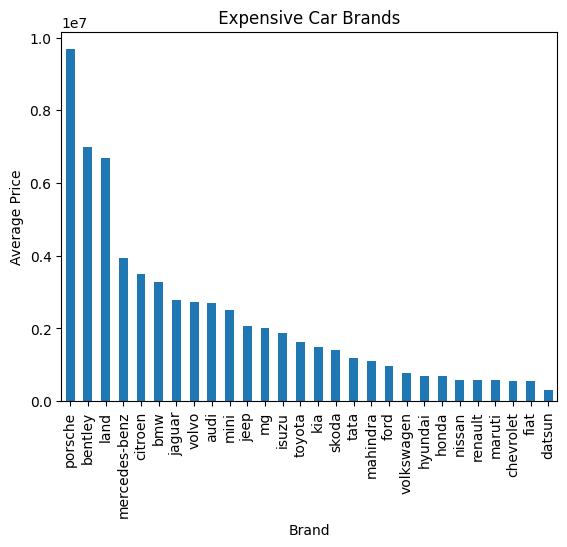

In [ ]:
#average price of cars brands wise also need descritive for chart or we need table
avg_price = df.groupby('brand')['car_price_in_rupees'].mean().sort_values(ascending=False)

avg_price.plot(kind='bar')

plt.title(' Expensive Car Brands ')
plt.xlabel('Brand')
plt.ylabel('Average Price')

plt.show()

This bar chart shows the average price of cars across different brands. From the visualization, we can observe that premium brands like Porsche, Land Rover, and BMW have the highest average prices, indicating they belong to the luxury segment. Mid-range brands such as Mercedes-Benz, Audi, and Jaguar also show relatively high prices but are slightly lower compared to top luxury brands. On the other hand, brands like Maruti, Hyundai, Chevrolet, and Datsun have lower average prices, representing budget-friendly or economy cars. This analysis clearly indicates that the brand of a car has a strong impact on its price

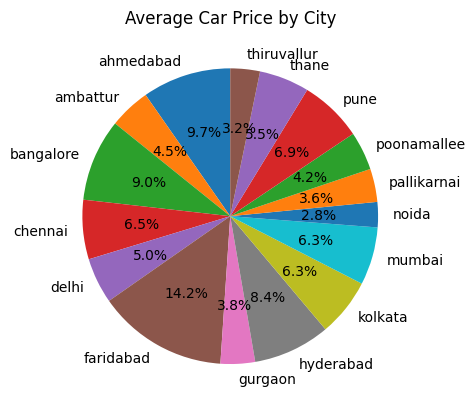

In [ ]:
#average car price groupeby city
city_avg_price = df.groupby('city')['car_price_in_rupees'].mean()
plt.pie(city_avg_price, labels=city_avg_price.index, autopct='%1.1f%%', startangle=90)
plt.title('Average Car Price by City')
plt.show()

This pie chart represents the average car price distribution across different cities. From the chart, we can see that Faridabad has the highest share, indicating that cars in this city have the highest average price among all cities. Cities like Ahmedabad, Bangalore, Hyderabad, Kolkata, and Mumbai also contribute a significant portion, showing relatively higher car prices. On the other hand, cities such as Noida, Pallikarnai, and Poonamallee have smaller shares, indicating lower average car prices. This analysis suggests that the city location plays an important role in determining car prices.

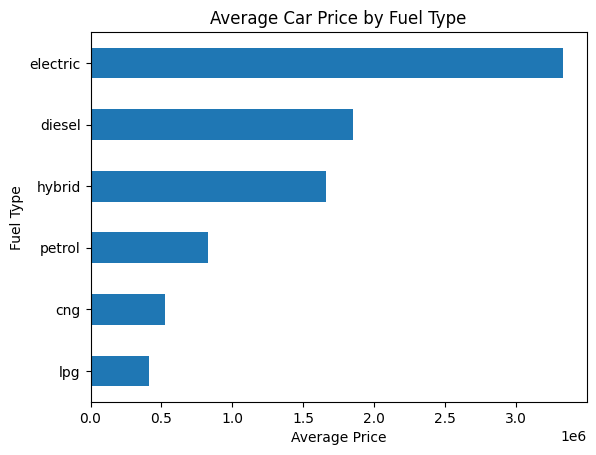

In [ ]:
#average price of group  by  fuel type wise  kind='barh' this is use for horizonal bar chart

avg_price = df.groupby('fuel_type')['car_price_in_rupees'].mean().sort_values()

avg_price.plot(kind='barh')

plt.title('Average Car Price by Fuel Type')
plt.xlabel('Average Price')
plt.ylabel('Fuel Type')

plt.show()

This bar chart shows the average car price based on different fuel types. From the chart, we can observe that electric cars have the highest average price, indicating they are more expensive due to advanced technology and newer features. Diesel and hybrid cars also have relatively high average prices, but lower than electric vehicles. Petrol cars fall in the mid-range category, while CNG and LPG cars have the lowest average prices, making them more affordable options. This analysis shows that fuel type has a significant impact on car pricing.

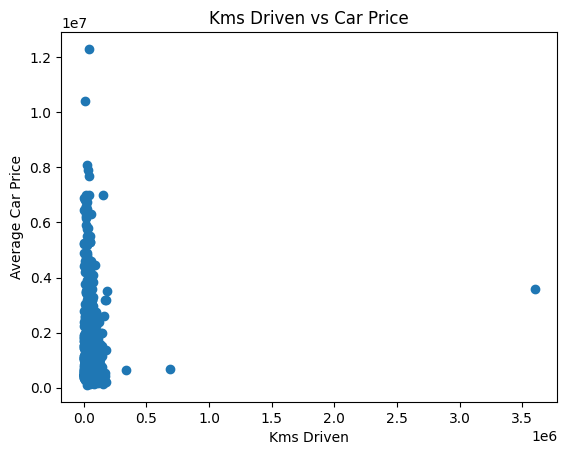

In [ ]:
# #average price of group by kms_driven wise also use line graph becouse colemn number to number 
avg_price = df.groupby('kms_driven')['car_price_in_rupees'].mean().sort_values()

plt.scatter(avg_price.index,avg_price.values)

plt.title('Kms Driven vs Car Price')
plt.xlabel('Kms Driven')
plt.ylabel('Average Car Price')

plt.show()

This scatter plot shows the relationship between kilometers driven and car price. From the chart, we can observe that cars with lower kilometers driven tend to have higher prices, while cars with higher mileage generally have lower prices. This indicates a negative relationship between mileage and car price, as vehicles lose value with increased usage. However, there are a few outliers where some cars have high mileage but still maintain relatively higher prices, possibly due to brand value or model type. Overall, this analysis shows that kilometers driven is an important factor affecting car price.

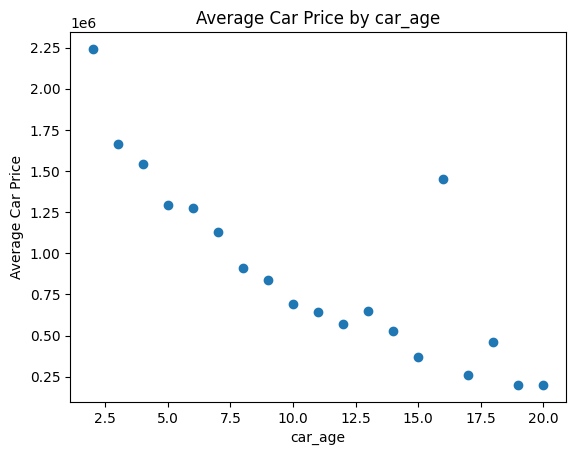

In [ ]:

#group by car_age  car price  wise also use line graph becouse colemn number to number
avg_price = df.groupby('car_age')['car_price_in_rupees'].mean().sort_values()


plt.scatter(avg_price.index, avg_price.values)
plt.xlabel("car_age")
plt.ylabel("Average Car Price")
plt.title("Average Car Price by car_age")
plt.show()

This scatter plot shows the relationship between car age and average car price. From the chart, we can clearly observe that as the car age increases, the average price decreases. This indicates a negative relationship between car age and price, meaning older cars tend to have lower prices due to depreciation. Newer cars (with lower age) have higher prices, while older cars become more affordable over time. This analysis confirms that car age is an important factor influencing car price

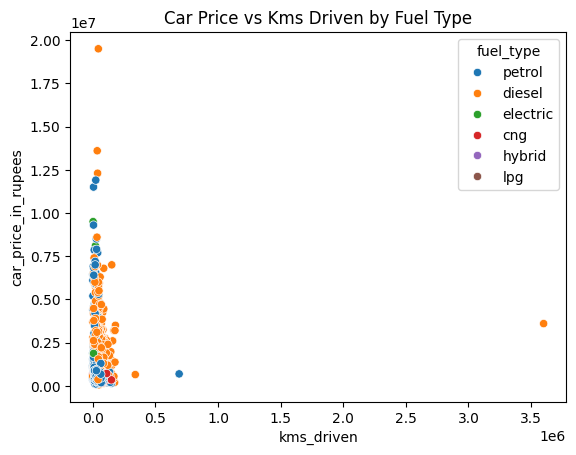

In [ ]:
# scatter plot of kmsdriven vs car price with fultype 
sns.scatterplot(x='kms_driven', y='car_price_in_rupees', hue='fuel_type', data=df)
plt.title("Car Price vs Kms Driven by Fuel Type")
plt.show()

This scatter plot shows the relationship between kilometers driven and car price, categorized by fuel type. From the chart, we can observe that across all fuel types, cars with lower kilometers driven generally have higher prices, indicating a negative relationship between mileage and price. Diesel cars show a wider spread and include some of the highest-priced vehicles, while petrol cars are more concentrated in the mid-price range. Electric and hybrid cars tend to have higher prices even at lower mileage, reflecting their newer technology. CNG and LPG cars are mostly clustered in the lower price range. Overall, this analysis shows that both mileage and fuel type significantly influence car prices.

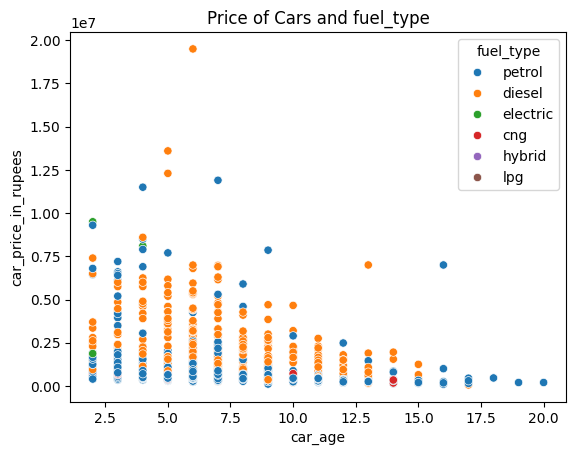

In [ ]:
#line plot of car_age vs car price with fuel type as hue also we can use line plot but scatter plot is better for these kind of data
sns.scatterplot(x = 'car_age', y = 'car_price_in_rupees', data = df, hue = 'fuel_type')
plt.title('Price of Cars and fuel_type')
plt.show()

The scatter plot shows the relationship between car age and car price (in rupees). Each point in the chart represents an individual car. The position of the point indicates its age on the horizontal axis and its price on the vertical axis. Different colors are used to represent various fuel types, including petrol, diesel, electric, CNG, hybrid, and LPG. This visualization helps in understanding how car price varies with age and how different fuel types are distributed across price ranges.

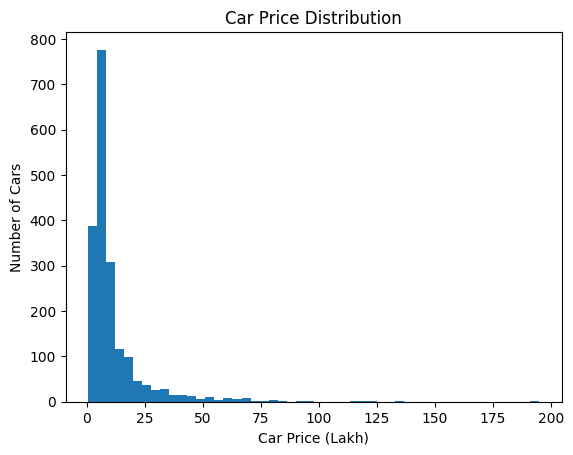

In [ ]:
# count car price distribution and target exploration  and creat a new column price leakh
df['price_lakh'] = df['car_price_in_rupees'] / 100000

plt.hist(df['price_lakh'], bins=50)

plt.title('Car Price Distribution')
plt.xlabel('Car Price (Lakh)')
plt.ylabel('Number of Cars')

plt.show()

df.drop('price_lakh', axis=1, inplace=True)

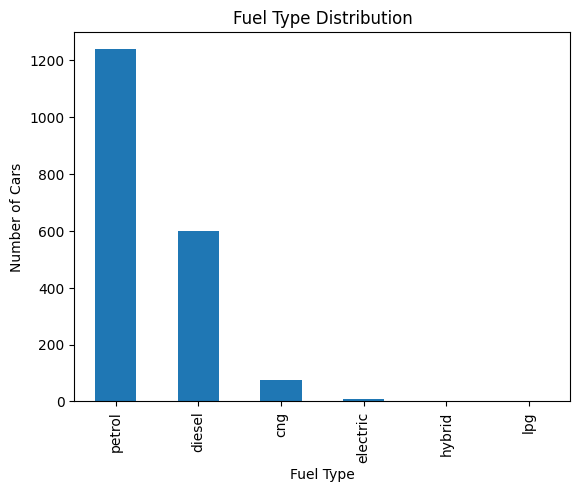

In [ ]:
#fuel type distribution

 #distribution of fuel type
#df['fuel_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90) this pie chart
        #OR
#sns.countplot(x='fuel_type', data=df)


            # OR 
df['fuel_type'].value_counts().plot(kind='bar')

plt.title('Fuel Type Distribution')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')

plt.show()

The chart shows the distribution of cars based on fuel type in the dataset. Each fuel category represents a different type of fuel used by vehicles, including petrol, diesel, CNG, electric, hybrid, and LPG. Petrol cars have the highest count with 1301 vehicles, making them the most dominant fuel type, followed by diesel cars with 620 vehicles. CNG cars have a smaller presence with 79 vehicles, while electric cars are very limited with only 9 entries. Hybrid and LPG cars are the least represented, with just 2 vehicles each. This distribution indicates that traditional fuel types like petrol and diesel are far more common in the dataset compared to alternative fuel options.

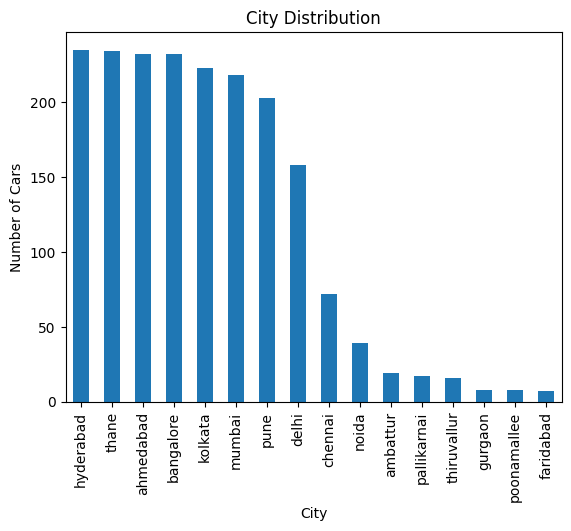

In [ ]:
#city wise car distribution
df['city'].value_counts().plot(kind='bar')

plt.title('City Distribution')
plt.xlabel('City')
plt.ylabel('Number of Cars')

plt.show()

The chart shows the distribution of cars across different cities in the dataset. Each value represents the number of cars available in a particular city. Cities such as Bangalore (240), Hyderabad (240), Ahmedabad (239), Thane (239), Kolkata (234), Mumbai (232), and Pune (225) have the highest number of cars, indicating strong market presence in these locations. Delhi also has a significant count with 174 cars. On the other hand, cities like Chennai (75) and Noida (40) have a moderate number of vehicles. Smaller counts are observed in cities such as Ambattur (19), Pallikarnai (17), Thiruvallur (16), Gurgaon (8), Poonamallee (8), and Faridabad (7), showing limited representation. This distribution highlights that car availability is concentrated in major metropolitan areas, while smaller cities have fewer listings

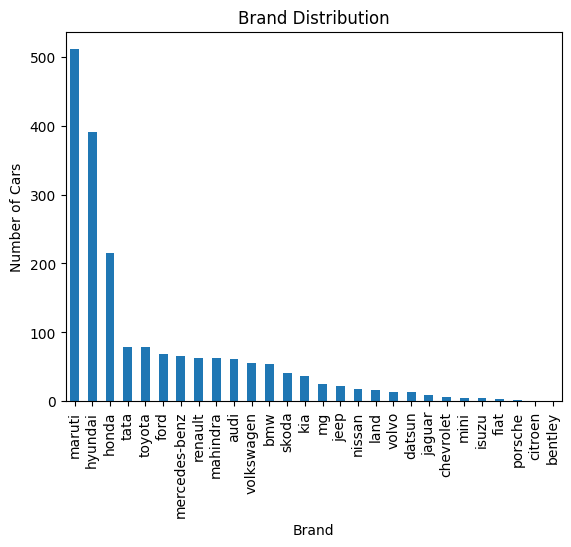

In [ ]:
#brand wise car distribution
df['brand'].value_counts().plot(kind='bar')

plt.title('Brand Distribution')
plt.xlabel('Brand')
plt.ylabel('Number of Cars')

plt.show()

The image shows a close-up view of a porous, sponge-like structure. The material has an uneven surface with numerous small holes and cavities, indicating a lightweight and airy composition. The texture appears rough and irregular, with a network-like pattern formed by interconnected pores. This type of structure is commonly seen in baked or foam-based materials, where air pockets are trapped within the substance. The visual highlights how the internal structure contributes to the overall texture and density of the material.

In [ ]:
#for final view of eda
df.head()

,brand,model,car_price_in_rupees,kms_driven,fuel_type,city,car_age
0,hyundai,grand i10 magna 1.2 kappa vtvt [2017-2020],445000,22402,petrol,mumbai,8
1,maruti,suzuki alto 800 lxi,293000,10344,petrol,kolkata,5
2,tata,safari xz plus new,2249000,12999,diesel,bangalore,3
3,maruti,suzuki ciaz zxi+,695000,45000,petrol,thane,8
4,jeep,compass sport plus 1.4 petrol [2019-2020],1200000,11193,petrol,kolkata,5


# DATA PREPROCCSING PART 2

FEATUER ENGINEERING = encode  + target encoded + ouleir find + standet scaler + corriletion

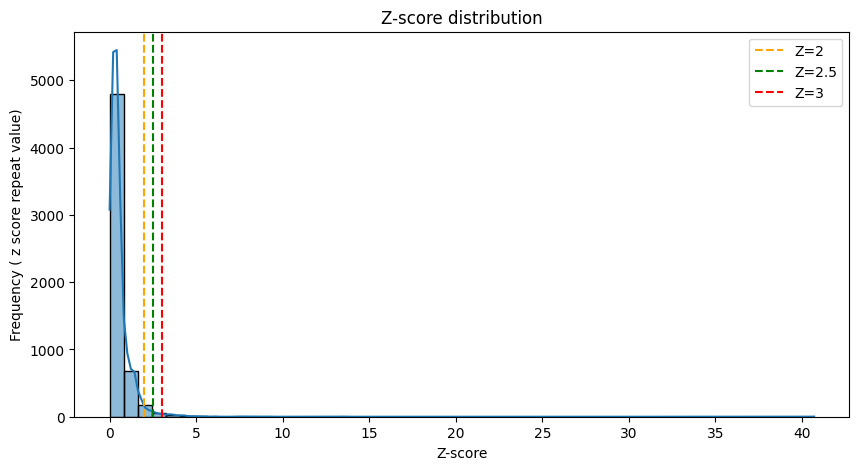

In [ ]:
#FINDIN THE OUTLYERS AND REMOVE
import numpy as np
from scipy import stats

# histogram is barchar find the final like green line 2.5 that is good threshhold
numeric_cols = df.select_dtypes(include=[np.number]).columns

z_scores = np.abs(stats.zscore(df[numeric_cols]))

# Z-score histogram
plt.figure(figsize=(10,5))
sns.histplot(z_scores.flatten(), bins=50, kde=True)
plt.axvline(2, color='orange', linestyle='--', label='Z=2')
plt.axvline(2.5, color='green', linestyle='--', label='Z=2.5')
plt.axvline(3, color='red', linestyle='--', label='Z=3')
plt.title("Z-score distribution")
plt.xlabel("Z-score")
plt.ylabel("Frequency ( z score repeat value)")
plt.legend()
plt.show()

In [ ]:
# Label Encode brand & fuel_type
le_brand = LabelEncoder()
df['brand_encoded'] = le_brand.fit_transform(df['brand'])

le_fuel = LabelEncoder()
df['fuel_type_encoded'] = le_fuel.fit_transform(df['fuel_type'])


# Optional: model can also be label encoded if too many unique
#le_model = LabelEncoder()
#df['model_encoded'] = le_model.fit_transform(df['model'])

In [ ]:
# One-Hot Encode city
df = pd.get_dummies(df, columns=['city'], drop_first=True)
## Some time when we do encoding we miss the some category to get column like cutomer churn project that time use this


# df['Contract'] = df['Contract'].str.strip()  # Extra spaces நீக்கும்
# df['Contract'] = df['Contract'].str.title()  # First letter capital, rest small, optional

# # 2️⃣ Explicitly define all categories
# df['Contract'] = pd.Categorical(df['Contract'], 
#                                 categories=['Month-to-month','One year','Two year'])

# # 3️⃣ One-hot encoding
# df = pd.get_dummies(df, columns=['Contract'], drop_first=False)

In [ ]:
#drop th old colums 
df = df.drop(columns=['brand', 'fuel_type'])

In [ ]:
#this is importent  this is call target encoding so many uniq value that reson choosh the model for  targer encodig
# Model column-ஐ car_price_in rupees target அடிப்படையில் encode செய்ய this new column
target_mean = df.groupby('model')['car_price_in_rupees'].mean()

df['model_target_encoded'] = df['model'].map(target_mean)

df = df.drop(columns=['model'])

df[['model_target_encoded']].head()

,model_target_encoded
0,4.653635e+05
1,2.973529e+05
2,2.249000e+06
3,6.670000e+05
4,1.200000e+06


In [ ]:
df.head()

,car_price_in_rupees,kms_driven,car_age,brand_encoded,fuel_type_encoded,city_ambattur,city_bangalore,city_chennai,city_delhi,city_faridabad,...,city_hyderabad,city_kolkata,city_mumbai,city_noida,city_pallikarnai,city_poonamallee,city_pune,city_thane,city_thiruvallur,model_target_encoded
0,445000,22402,8,9,5,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,4.653635e+05
1,293000,10344,5,16,5,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,2.973529e+05
2,2249000,12999,3,24,1,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,2.249000e+06
3,695000,45000,8,16,5,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,6.670000e+05
4,1200000,11193,5,12,5,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,1.200000e+06


In [ ]:
#remove the   outlears and new data in df_clean and use untill model 
from scipy import stats

numeric_cols = ['car_price_in_rupees', 'kms_driven', 'car_age']
z = np.abs(stats.zscore(df[numeric_cols]))
df_clean = df[(z < 2.5).all(axis=1)]  # z-score > 2.5 values remove
print("Rows after outlier removal:", df_clean.shape)

Rows after outlier removal: (1830, 21)


In [ ]:
#New data after removing outlears
df_clean.head()

,car_price_in_rupees,kms_driven,car_age,brand_encoded,fuel_type_encoded,city_ambattur,city_bangalore,city_chennai,city_delhi,city_faridabad,...,city_hyderabad,city_kolkata,city_mumbai,city_noida,city_pallikarnai,city_poonamallee,city_pune,city_thane,city_thiruvallur,model_target_encoded
0,445000,22402,8,9,5,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,4.653635e+05
1,293000,10344,5,16,5,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,2.973529e+05
2,2249000,12999,3,24,1,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,2.249000e+06
3,695000,45000,8,16,5,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,6.670000e+05
4,1200000,11193,5,12,5,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,1.200000e+06


<Axes: >

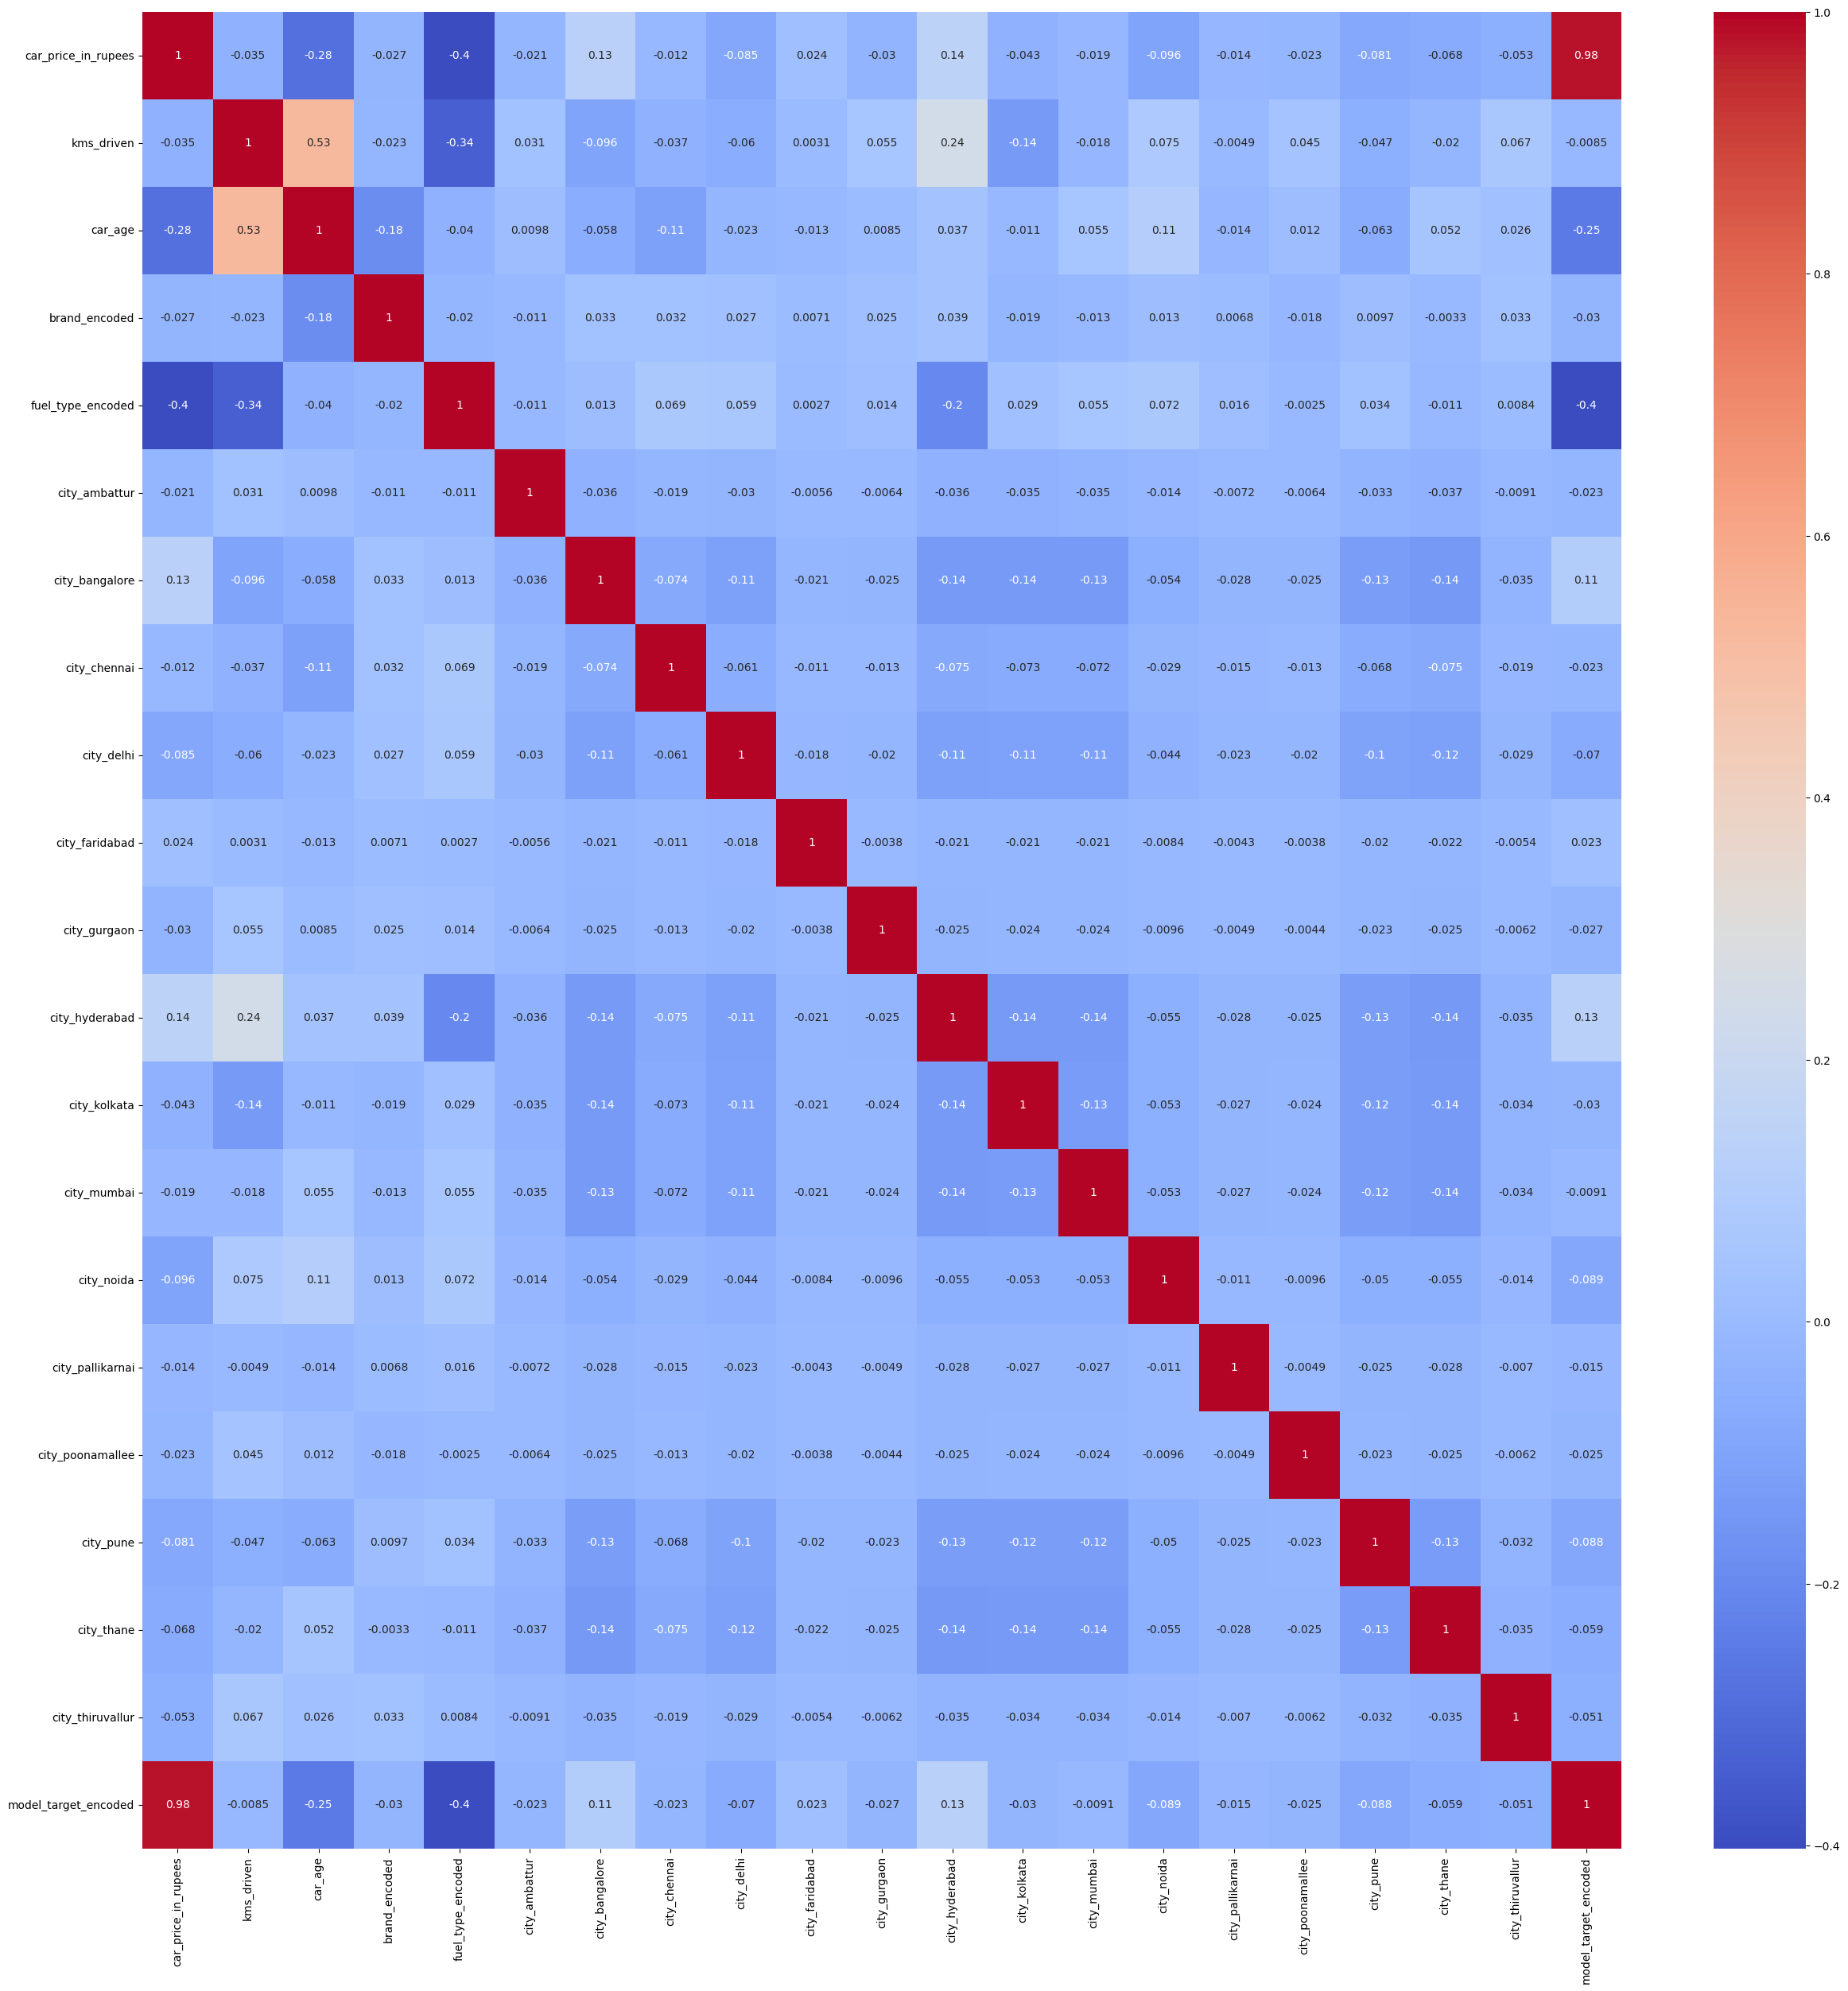

In [ ]:
#corrilation of data to df_clean need marke down
plt.figure(figsize=(30,30))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')


no need satadet scaler for rendomforet  model

# MODEL CREAT 
= TRAIN and test + model bulting + MODEL EVALUTION

TRAIN AND TEST 

In [ ]:

# train and test slpte to df_clean 
y = df_clean['car_price_in_rupees']
X = df_clean.drop(columns=['car_price_in_rupees'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

MODEL BULDING

In [ ]:
#bulid model menualy

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=250,        # enough trees
    max_depth=14,            # allow moderate depth
    min_samples_split=5,     # avoid tiny splits
    min_samples_leaf=3,      # each leaf ≥ 3 samples
    max_features='sqrt',     # subset of features per split
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

ΔR² (Train – Test) Acceptable vs Unacceptable
ΔR² (Train R² – Test R²)	Meaning
0 – 0.10	Excellent, model well-generalized
0.10 – 0.20	Acceptable, slight overfitting
0.20 – 0.30	Warning, overfitting noticeable
>0.30	Bad, severe overfitting

In [ ]:
# # model bulid atometicly 

# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor


# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf = RandomForestRegressor(random_state=42)

# grid_search = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     cv=5,             # 5-fold cross-validation
#     n_jobs=-1,        # all CPU cores
#     scoring='r2',     # optimize R²
#     verbose=2
# )



# grid_search.fit(X_train, y_train)


# print("Best Parameters:", grid_search.best_params_)

# best_rf = grid_search.best_estimator_

# y_pred_train = best_rf.predict(X_train)
# y_pred_test = best_rf.predict(X_test)

# print("Train R2:", r2_score(y_train, y_pred_train))
# print("Test R2:", r2_score(y_test, y_pred_test))

MODEL EVALUETION




MAE = avrag  this is avrage erorr and find fit 
MSE = VERIEYENCE 
RMSE = SANDET DIVISION  rang of erorr

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# =========================
# Predictions
# =========================
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

y_train_pred = rf.predict(X_train)   # ✅ இது add பண்ணணும்
y_test_pred = rf.predict(X_test)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)



# =========================
# Errors
# =========================
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

#rmse formula
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

# =========================
# Print Results
# =========================
#model evalution 

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))



print("🔹 TRAIN")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)

print("\n🔹 TEST")
print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE:", test_rmse)



# =========================
# Fit Check Logic
# =========================
print("\n🔍 MODEL FIT CHECK")

if train_rmse < test_rmse * 0.7:
    print("❌ Overfitting (Train error low, Test error high)")

elif train_rmse > test_rmse * 1.3:
    print("⚠️ Unusual case (check data)")

elif train_rmse > 300000 and test_rmse > 300000:
    print("❌ Underfitting (Both errors high)")

else:
    print("✅ Good Fit")

# FEATUER IMPORTENCE 
this non liner thar reason use rf.feature_importances
if this have liner data use coeffcient and Intercept


In [ ]:
#creat new df featuer and importence 
feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
feat_df = feat_df.sort_values(by='Importance', ascending=False).round(3)
feat_df

,Feature,Importance
19,model_target_encoded,0.632
2,brand_encoded,0.143
3,fuel_type_encoded,0.096
1,car_age,0.061
0,kms_driven,0.039
5,city_bangalore,0.010
10,city_hyderabad,0.005
17,city_thane,0.003
11,city_kolkata,0.003
7,city_delhi,0.002


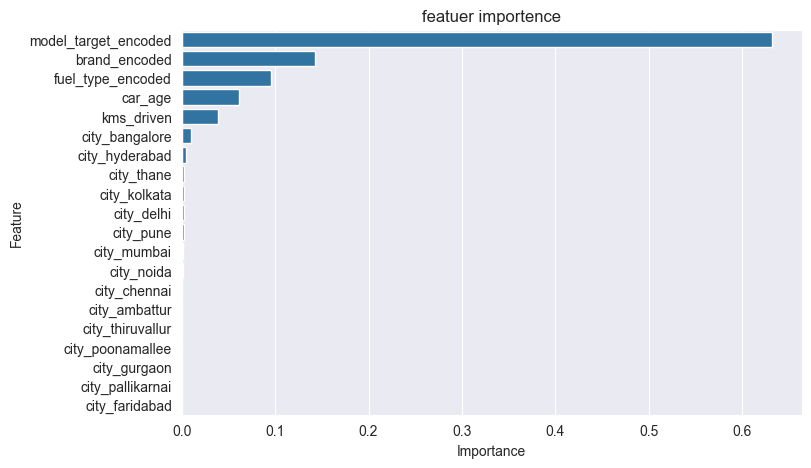

In [ ]:
#featuer impotence in ghraph 
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=feat_df)
plt.title( "featuer importence")
plt.show()

The bar chart shows the importance of different features in predicting car price. Each bar in the chart represents a feature used in the model, and the length of the bar indicates its level of importance. Features such as model, brand, fuel type, car age, and kilometers driven are included. The most important feature has the longest bar, indicating it has the strongest influence on the predicted price, while features with shorter bars have less impact. This visualization helps in understanding which factors contribute the most to car price prediction and how different variables influence the model’s decision

SAVE THE MODEL

In [ ]:
#chek model by encoded sright
import pandas as pd

# Assuming X_train.columns is your training feature list
all_columns = X_train.columns

input_dict = {
    'kms_driven': 10344,
    'car_age': 5,
    'brand_encoded': 16,
    'fuel_type_encoded': 5,
    'city_ambattur': False,
    'city_bangalore': False,
    'city_chennai': False,
    'city_delhi': False,
    'city_faridabad': False,
    'city_gurgaon': False,
    'city_hyderabad': False,
    'city_kolkata': True,
    'city_mumbai': False,
    'city_noida': False,
    'city_pallikarnai': False,
    'city_poonamallee': False,
    'city_pune': False,
    'city_thane': False,
    'city_thiruvallur': False,
    'model_target_encoded': 297352.94
}

new_car = pd.DataFrame([{col: input_dict.get(col, False) for col in all_columns}])

pred_price = rf.predict(new_car)
print(f"Predicted Car Price: ₹{pred_price[0]:,.2f}")

Predicted Car Price: ₹469,098.47


In [ ]:
# after save the model 
# During training
import joblib



# Save model
joblib.dump(rf, "USED_CAR_price_model .pkl")



# Save X_train columns
joblib.dump(list(X_train.columns), "x_train_columns.pkl")
# ALL LEBLE ENCODETE SAVE AS A PLK FILL
import joblib

joblib.dump(target_mean, "target_mean.pkl")



joblib.dump(le_fuel, "fuel_type_encoded.pkl")


joblib.dump(le_brand, "brand_encoded.pkl")

print(X_train.columns)




Index(['kms_driven', 'car_age', 'brand_encoded', 'fuel_type_encoded',
       'city_ambattur', 'city_bangalore', 'city_chennai', 'city_delhi',
       'city_faridabad', 'city_gurgaon', 'city_hyderabad', 'city_kolkata',
       'city_mumbai', 'city_noida', 'city_pallikarnai', 'city_poonamallee',
       'city_pune', 'city_thane', 'city_thiruvallur', 'model_target_encoded'],
      dtype='object')
